# Import packages to be used

In [8]:
#Import packages
import matplotlib.pyplot as plt
import pandas as pd

## Create dataframes from raw csv files
first five rows of each displayed, rather than printed, using IPython.display module - preloaded in a the notebook environment

In [21]:
# Create DataFrames from the CSVs
customers_df = pd.read_csv('customers.csv')
orders_df = pd.read_csv('orders.csv')
products_df = pd.read_csv('products.csv')

#Display the first few rows of each DataFrame
print("Customers:")
display(customers_df.head())
print("Products:")
display(products_df.head())
print("Orders:")
display(orders_df.head())


Customers:


,customer_id,first_name,last_name,email,city,region,country,signup_date,age,is_subscribed,loyalty_tier
0,CUST-0001,James,Brown,james.brown@gmail.com,London,England,United Kingdom,2022-01-31,65,True,Bronze
1,CUST-0002,Emily,Campbell,emily.campbell@outlook.com,Birmingham,England,United Kingdom,2023-09-25,55,True,Bronze
2,CUST-0003,Arthur,Roberts,arthur.roberts@icloud.com,London,England,United Kingdom,2021-03-25,53,False,Bronze
3,CUST-0004,Freddie,Murphy,freddie.murphy@outlook.com,London,England,United Kingdom,2020-10-15,66,False,Bronze
4,CUST-0005,Leo,Stewart,leo.stewart@hotmail.com,Glasgow,Scotland,United Kingdom,2020-01-15,24,False,Bronze


Products:


,product_id,product_name,category,price,cost,stock_quantity,supplier
0,PRD_001,Smart Webcam,Electronics,125.21,91.76,322,TD SYNNEX
1,PRD_002,Smart Speaker,Electronics,336.32,191.26,469,TD SYNNEX
2,PRD_003,Rechargeable Speaker,Electronics,150.81,79.02,574,Tech Data
3,PRD_004,Wireless Router,Electronics,149.79,93.68,597,Exertis
4,PRD_005,4K Monitor,Electronics,196.94,147.55,141,Tech Data


Orders:


,order_id,customer_id,product_id,order_date,quantity,unit_price,total_amount,order_status,payment_method
0,ORD-000001,CUST-0251,PRD_328,2023-02-21,1,27.96,27.96,Completed,Credit Card
1,ORD-000002,CUST-0033,PRD_347,2023-06-28,5,51.74,258.70,Completed,Debit Card
2,ORD-000003,CUST-0734,PRD_120,2023-02-24,5,96.94,484.70,Completed,Google Pay
3,ORD-000004,CUST-0829,PRD_215,2025-07-08,2,35.22,70.44,Pending,Debit Card
4,ORD-000005,CUST-0221,PRD_358,2024-11-27,4,10.92,43.68,Returned,PayPal


## Analysing some customer data


There are a total of 61 customers in Glasgow


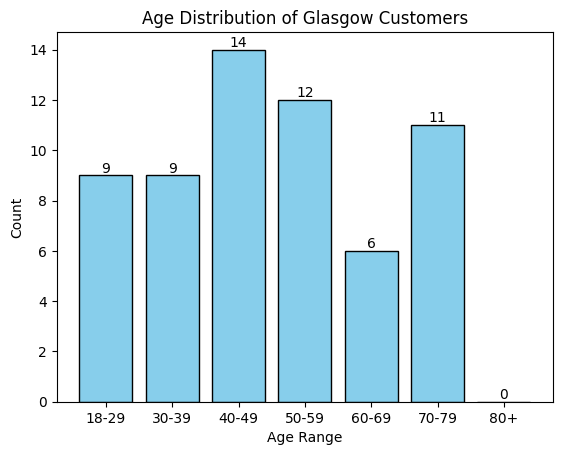

In [22]:
# Generate a DataFrame and age distribution graph for each city's customers
cities = customers_df['city'].unique()
bins = [18, 30, 40, 50, 60, 70, 80, 100]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

city_customers_dfs = {city: customers_df[customers_df['city'] == city] for city in cities}

city = "Glasgow" # Change this to the city you want to analyze
city_customers = city_customers_dfs[city]

#Alternatively, us the following for loop to generate graphs for all cities:
#for city, city_customers in city_customers_dfs.items():
print(f"There are a total of {len(city_customers)} customers in {city}")
if not city_customers.empty:
    city_customers['age_group'] = pd.cut(city_customers['age'], bins=bins, labels=labels, right=False)
    age_counts = city_customers['age_group'].value_counts().sort_index()
    plt.bar(age_counts.index, age_counts.values, color='skyblue', edgecolor='black')
    plt.title(f'Age Distribution of {city} Customers')
    plt.xlabel('Age Range')
    plt.ylabel('Count')
    for i, v in enumerate(age_counts.values):
        plt.text(i, v, int(v), ha='center', va='bottom')
    plt.show()
else:
    print(f'No customers found for {city}.')
